In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))


# read_colvar function which sorts colvar for unique entries from the back (i.e., second entry retained)
def read_colvar(colvar_file):

    data = np.loadtxt(colvar_file)
    # inverse order
    data = data[::-1]
    unique_idxs = np.array(np.unique(data[:,0], return_index=True)[1]).astype(int)[::-1] # find unique indices, first occurences
    data = data[unique_idxs]
    # original order
    data = data[::-1]

    return data


path = '/Volumes/Elements/PTM_project/FLNC24/METAD_repeat/DATA_PLUMED/'

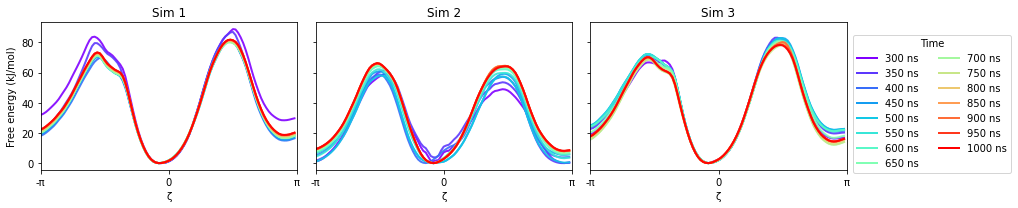

In [2]:


T = 298
sims = [1, 2, 3]

times = np.arange(300, 1050, 50)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

frame_per_ns = 1000 / 5
init_frame = int(200 * frame_per_ns)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Create legend handles (one per time)
legend_handles = [
    plt.Line2D([0], [0], color=c, lw=2, label=f'{t} ns')
    for t, c in zip(times, colors)
]

for ax, sim in zip(axes, sims):

    data = np.loadtxt(path + f'COLVAR.{sim}')
    CV = data[:, 1]
    rbias = data[:, 3]

    for t, c in zip(times, colors):

        frame = int(t * frame_per_ns)
        if frame <= init_frame:
            continue

        kbt = 0.008314 * T

        rb_slice = rbias[init_frame:frame]
        cv_slice = CV[init_frame:frame]

        weights = np.exp((rb_slice - np.max(rb_slice)) / kbt)
        weights /= np.sum(weights)

        hist, x = np.histogram(cv_slice, weights=weights, bins=100)
        p = hist / np.sum(hist)
        p[p == 0] = 1e-12

        fel = -kbt * np.log(p)
        fel = scipy.ndimage.gaussian_filter(fel, sigma=1)
        fel -= np.min(fel)

        ax.plot(x[:-1], fel, color=c, alpha=0.9, lw=2)

    ax.set_title(f'Sim {sim}')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels(['-\u03C0',0,'\u03C0'])
    ax.set_xlabel('\u03B6')

axes[0].set_ylabel('Free energy (kJ/mol)')

# Add a single shared legend
fig.legend(
    handles=legend_handles,
    loc='center right',
    title='Time',
    ncol=2,
    bbox_to_anchor=(1.18, 0.5)
)

plt.tight_layout()
plt.savefig('rbias_zeta_FEL_timecourse_all_sims.pdf', dpi=300, bbox_inches='tight')




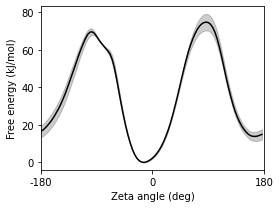

In [13]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Zeta angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_zeta.png')

In [14]:
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis.csv')
df

,Avg %,Err %
0,98.4,1.2


In [15]:
cis_data

[0.9994421443107828, 0.9555810605434842, 0.9965998029873121]

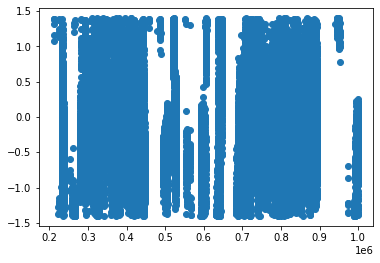

In [16]:
plt.scatter(data[:,0][init_frame:frame][cisframes],CV[init_frame:frame][cisframes])

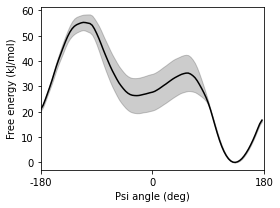

In [17]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))
    CV = data[:,2]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Psi angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_psi.png')

In [18]:
## COMPARISON WITH FINAL BIAS

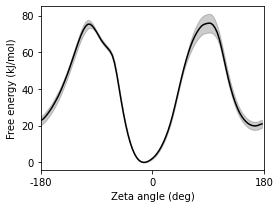

In [19]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(200,1020,20)
t=times[-1] # at 1000ns, no transient discarded using total final bias

fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/20) # 20 ps frequency for COLVAR_REW
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[:frame]-np.amax(rbias[:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Zeta angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_zeta_finalbias.png')

In [20]:
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(200,1020,20)
t=times[-1] # at 1000ns


cis_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/20) # 20 ps frequency for COLVAR_REW
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[:frame]-np.amax(rbias[:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis_finalbias.csv')
df

,Avg %,Err %
0,99.9,0.0
